# My Intraday Momentum Strategy for SPY
Variation with an RSI scaling of the leverage, a lunch-time entry filter and a breadth filter with RSP (S&P 500 equal weight). The breadth filter is shown in **both directions**:

- **RSP confirm**: a SPY breakout is only traded if RSP breaks out of its own Noise Area too (the move is carried by the broad market).
- **RSP contrarian**: a SPY breakout is only traded if RSP does *not* break out (the move is carried by the large caps).

All other settings (stop mode, multiplier, target volatility, leverage cap, RSI scaling, lunch filter) are read from `my_strategy.py`. Change them there, then re-run the notebook from the top. Only days with clean minute data for both SPY and RSP are traded, for every variant, so all comparisons use the same days.

In [1]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

import my_strategy
from config import END, START, TEST_START, TRAIN_END
from data import clean_minute_bars, load_daily_total_returns, load_minute_bars, make_daily_tables
from metrics import compute_equity_curve, compute_metrics
from paper_strategy import (
    compute_daily_volatility,
    compute_noise_area,
    compute_vwap,
    get_trading_times,
)

importlib.reload(my_strategy)  # pick up edits of my_strategy.py without restarting the kernel
from my_strategy import (
    LEVERAGE_MULTIPLIER,
    MAX_LEVERAGE,
    NO_ENTRY_END,
    NO_ENTRY_START,
    RSI_PERIOD,
    STOP_MODE,
    RSP_SYMBOL,
    TARGET_VOLATILITY,
    USE_LUNCH_FILTER,
    USE_RSI_SCALING,
    compute_rsi,
    compute_rsi_scale,
    compute_rsp_filter,
    count_daily_trades,
    get_common_days,
    run_ablation,
    run_my_backtest,
)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print(
    f"Selected in my_strategy.py: stop mode = {STOP_MODE}, multiplier = {LEVERAGE_MULTIPLIER}, "
    f"target volatility = {TARGET_VOLATILITY}, max leverage = {MAX_LEVERAGE}"
)
print(
    f"RSI scaling = {USE_RSI_SCALING} (period {RSI_PERIOD}), lunch filter = {USE_LUNCH_FILTER} "
    f"(no entries {NO_ENTRY_START:%H:%M} to {NO_ENTRY_END:%H:%M})"
)
print(f"RSP filter ({RSP_SYMBOL}): both modes are shown below, 'confirm' and 'contrarian'")

Selected in my_strategy.py: stop mode = band_vwap, multiplier = 1.0, target volatility = 0.02, max leverage = 4
RSI scaling = True (period 5), lunch filter = True (no entries 12:30 to 14:00)
RSP filter (RSP): both modes are shown below, 'confirm' and 'contrarian'


## 1. Data
RSP is much less liquid than SPY, especially in 2020. On days with fewer than 370 minute bars `clean_minute_bars` drops the day, so RSP is missing on some SPY days. The breadth filter cannot be evaluated on those days, so **only days with clean data for both ETFs are traded, for every variant**. This keeps the comparison fair: all strategies are measured on exactly the same days.

In [2]:
raw = load_minute_bars("SPY", START, END)
bars = clean_minute_bars(raw)
tables = make_daily_tables(bars)
# Benchmark: SPY on all trading days (not only the common days), adjusted for dividends and splits
benchmark_returns = load_daily_total_returns("SPY", START, END)
print(
    len(tables["close"]), "trading days from", tables["close"].index[0].date(), "to", tables["close"].index[-1].date()
)

# RSP (S&P 500 equal weight) with exactly the same functions, used for the breadth filter
rsp_tables = make_daily_tables(clean_minute_bars(load_minute_bars(RSP_SYMBOL, START, END)))
common_days = get_common_days(tables, rsp_tables)
missing_days = tables["close"].index.difference(common_days)
print(len(rsp_tables["close"]), f"RSP trading days, {len(missing_days)} SPY days without clean RSP data")
print("Missing days per year:", pd.Series(missing_days.year).value_counts().sort_index().to_dict())
print(
    f"All variants below are traded on the {len(common_days)} days with data for both ETFs "
    "(indicators still use the full SPY history)."
)

1687 trading days from 2020-01-02 to 2026-10-01


1562 RSP trading days, 125 SPY days without clean RSP data
Missing days per year: {2020: 105, 2021: 8, 2022: 10, 2025: 2}
All variants below are traded on the 1562 days with data for both ETFs (indicators still use the full SPY history).


## 2. Noise Area on single days
Same signal as in the paper strategy. 31 Jan 2022 is a clean upward trend, 20 Jan 2022 a reversal that the VWAP stop catches.

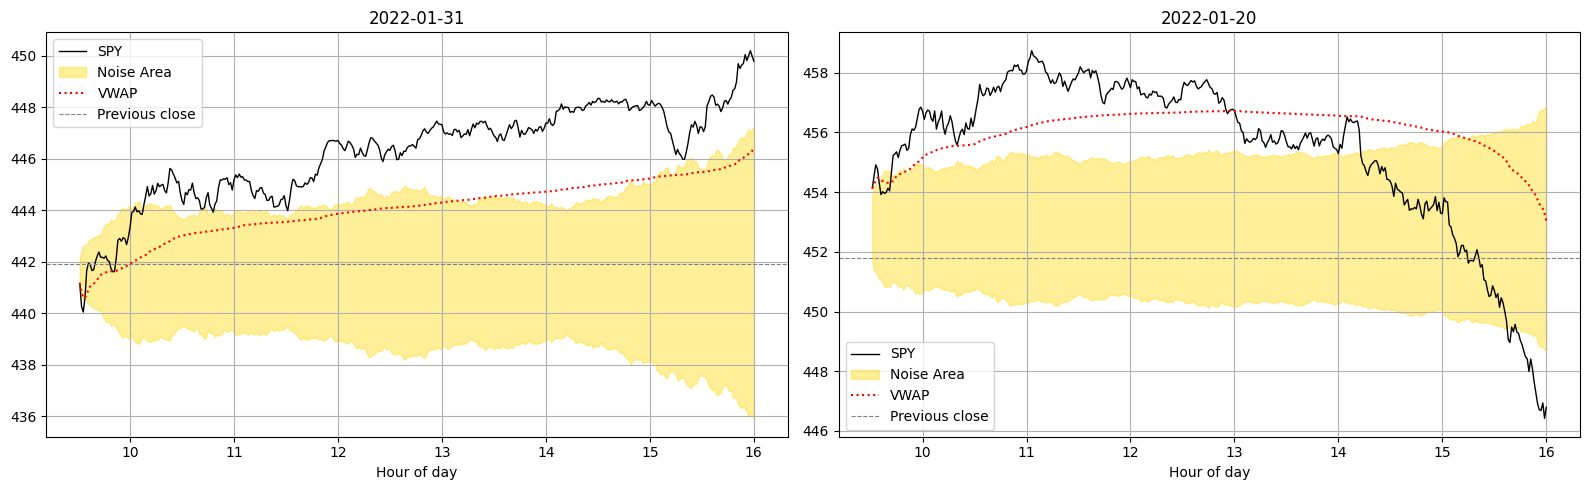

In [3]:
close = tables["close"]
upper, lower = compute_noise_area(close, tables["day_open"], tables["prev_close"])
vwap = compute_vwap(close, tables["volume"])
hours = [t.hour + t.minute / 60 for t in close.columns]


def plot_noise_area(date, ax):
    date = pd.Timestamp(date)
    ax.plot(hours, close.loc[date], color="black", linewidth=1, label="SPY")
    ax.fill_between(hours, lower.loc[date], upper.loc[date], color="gold", alpha=0.4, label="Noise Area")
    ax.plot(hours, vwap.loc[date], color="red", linestyle=":", label="VWAP")
    ax.axhline(tables["prev_close"].loc[date], color="gray", linestyle="--", linewidth=0.8, label="Previous close")
    ax.set_title(date.date())
    ax.set_xlabel("Hour of day")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_noise_area("2022-01-31", axes[0])
plot_noise_area("2022-01-20", axes[1])
plt.tight_layout()
plt.show()

### RSP filter
The RSP Noise Area is computed with the same 14-day rule as for SPY. Exits and stops are not affected by the filter. The plots show RSP on the same two days as above. The last lines show how SPY breakouts split between the two modes: with **confirm** only the breakouts that RSP confirms can be entered, with **contrarian** only the others.

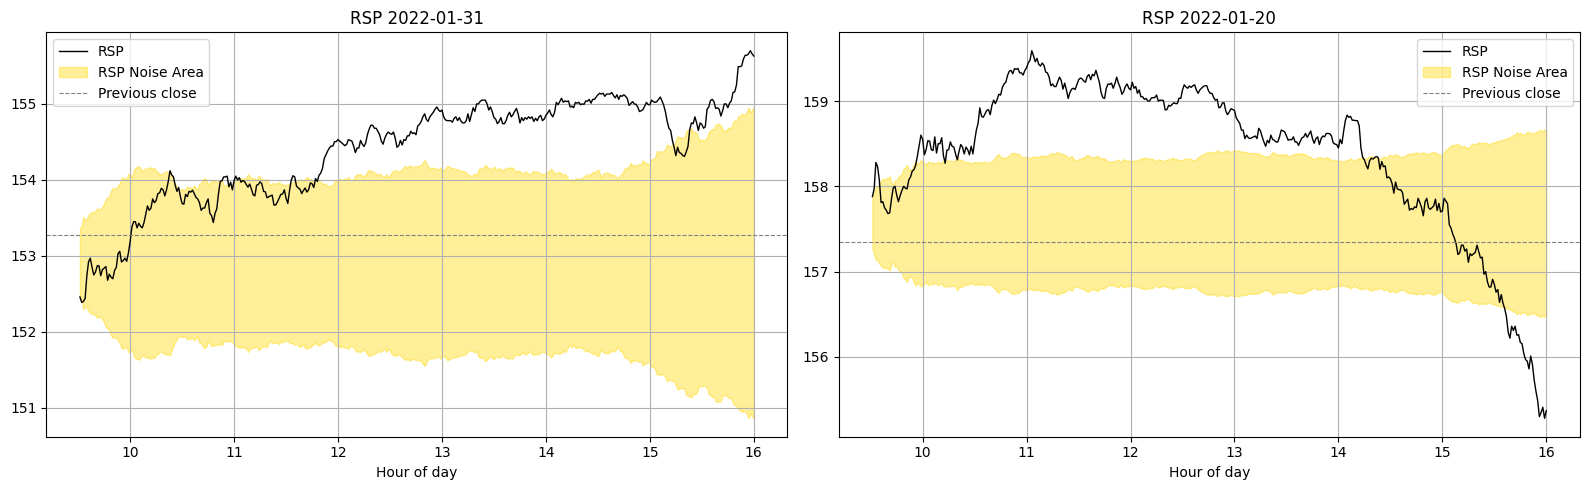

SPY above its upper band: 2995 time slots, allowed by confirm 56.5%, by contrarian 43.0%
SPY below its lower band: 2505 time slots, allowed by confirm 61.8%, by contrarian 36.7%


In [4]:
rsp_close = rsp_tables["close"]
rsp_upper, rsp_lower = compute_noise_area(rsp_close, rsp_tables["day_open"], rsp_tables["prev_close"])


def plot_rsp_noise_area(date, ax):
    date = pd.Timestamp(date)
    ax.plot(hours, rsp_close.loc[date], color="black", linewidth=1, label="RSP")
    ax.fill_between(hours, rsp_lower.loc[date], rsp_upper.loc[date], color="gold", alpha=0.4, label="RSP Noise Area")
    ax.axhline(rsp_tables["prev_close"].loc[date], color="gray", linestyle="--", linewidth=0.8, label="Previous close")
    ax.set_title(f"RSP {date.date()}")
    ax.set_xlabel("Hour of day")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_rsp_noise_area("2022-01-31", axes[0])
plot_rsp_noise_area("2022-01-20", axes[1])
plt.tight_layout()
plt.show()

times = get_trading_times(close.columns)
on_common = close.index.isin(common_days)[:, None]  # only days with RSP data
spy_long = (close[times] > upper[times]).to_numpy() & on_common
spy_short = (close[times] < lower[times]).to_numpy() & on_common
allowed = {mode: compute_rsp_filter(tables, rsp_tables, times, mode) for mode in ("confirm", "contrarian")}
for label, spy_breakout, side in [("above its upper band", spy_long, 0), ("below its lower band", spy_short, 1)]:
    shares = {mode: (spy_breakout & allowed[mode][side]).sum() / spy_breakout.sum() for mode in allowed}
    print(
        f"SPY {label}: {spy_breakout.sum()} time slots, allowed by confirm {shares['confirm']:.1%}, "
        f"by contrarian {shares['contrarian']:.1%}"
    )

## 3. Leverage policy
`leverage = min(MAX_LEVERAGE, LEVERAGE_MULTIPLIER * RSI_SCALE * TARGET_VOLATILITY / sigma)`, where sigma is the trailing 14-day standard deviation of SPY daily returns and `RSI_SCALE` is 1.0 when the RSI scaling is off. The paper policy (multiplier 1.0, no RSI scale) uses the same target and cap. The cap is applied after all scaling.

,Paper (x1.0),Mine (RSI scale)
count,1672.00,1672.00
mean,2.36,2.19
std,0.91,0.88
min,0.29,0.25
25%,1.67,1.51
50%,2.33,2.11
75%,3.01,2.77
max,4.00,4.00


Share of days at the leverage cap:


,share
Paper (x1.0),0.079
Mine (RSI scale),0.047


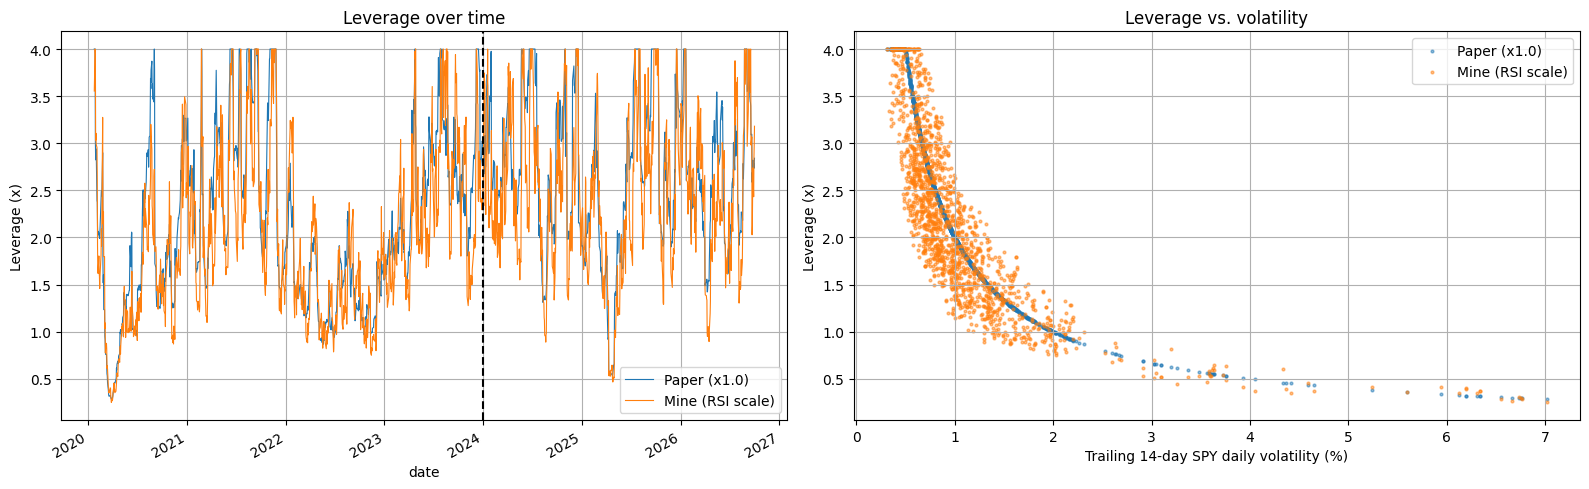

In [5]:
sigma = compute_daily_volatility(tables["close"]).dropna()
rsi_scale = compute_rsi_scale(compute_rsi(tables["close"])).reindex(sigma.index).fillna(1.0)
if not USE_RSI_SCALING:
    rsi_scale[:] = 1.0

leverage = pd.DataFrame(
    {
        "Paper (x1.0)": (TARGET_VOLATILITY / sigma).clip(upper=MAX_LEVERAGE),
        "Mine (RSI scale)": (LEVERAGE_MULTIPLIER * rsi_scale * TARGET_VOLATILITY / sigma).clip(upper=MAX_LEVERAGE),
    }
)
display(leverage.describe().round(2))
print("Share of days at the leverage cap:")
display((leverage >= MAX_LEVERAGE).mean().round(3).to_frame("share"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
leverage.plot(ax=axes[0], linewidth=0.8)
axes[0].axvline(pd.Timestamp(TEST_START), color="black", linestyle="--")
axes[0].set_title("Leverage over time")
axes[0].set_ylabel("Leverage (x)")
for column in leverage.columns:
    axes[1].scatter(sigma * 100, leverage[column], s=4, alpha=0.5, label=column)
axes[1].set_xlabel("Trailing 14-day SPY daily volatility (%)")
axes[1].set_ylabel("Leverage (x)")
axes[1].set_title("Leverage vs. volatility")
axes[1].legend()
plt.tight_layout()
plt.show()

### RSI scale
`scale = 1 + sensitivity * (50 - RSI) / 50`, clipped to the configured range. The RSI uses closes up to the previous day, so it is known at the open. Paper Section 4.5: a lower RSI is followed by a higher expected return, so the leverage is increased after pullbacks and reduced after rallies. The lunch filter (no new entries between the configured times) has no chart, it only removes entry slots.

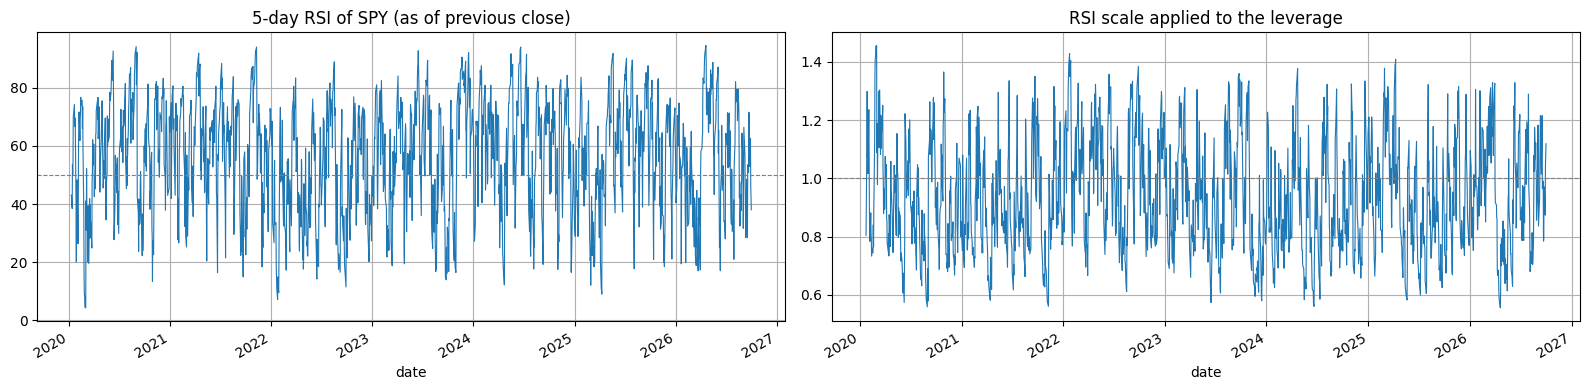

In [6]:
if USE_RSI_SCALING:
    rsi = compute_rsi(tables["close"]).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    rsi.plot(ax=axes[0], linewidth=0.8)
    axes[0].axhline(50, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_title(f"{RSI_PERIOD}-day RSI of SPY (as of previous close)")
    rsi_scale.plot(ax=axes[1], linewidth=0.8)
    axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_title("RSI scale applied to the leverage")
    plt.tight_layout()
    plt.show()
else:
    print("RSI scaling is switched off in my_strategy.py")

## 4. Backtest
Four variants with identical costs ($0.0035 commission and $0.001 slippage per share): fixed 100% exposure, the paper's dynamic sizing (no add-ons), and my strategy with the add-ons from `my_strategy.py` and the RSP filter in each direction. All variants are traded on the same days (data for both ETFs). SPY Buy&Hold is measured on every trading day from the first strategy day on, dividends reinvested, because a buy & hold investor cannot skip days.

In [7]:
addons = [name for name, on in [("RSI", USE_RSI_SCALING), ("Lunch", USE_LUNCH_FILTER)] if on]
mine_prefix = "Mine" + (f" ({' + '.join(addons)})" if addons else "")

off = dict(use_rsi_scaling=False, use_lunch_filter=False, rsp_mode="off")
mine = dict(
    sizing="dynamic",
    leverage_multiplier=LEVERAGE_MULTIPLIER,
    use_rsi_scaling=USE_RSI_SCALING,
    use_lunch_filter=USE_LUNCH_FILTER,
)
variants = {
    "Fixed 100%": dict(sizing="fixed", **off),
    "Paper (x1.0)": dict(sizing="dynamic", leverage_multiplier=1.0, **off),
    f"{mine_prefix}, RSP confirm": dict(rsp_mode="confirm", **mine),
    f"{mine_prefix}, RSP contrarian": dict(rsp_mode="contrarian", **mine),
}
mine_names = [name for name in variants if name.startswith("Mine")]

strategy_returns = {}
for name, kwargs in variants.items():
    strategy_returns[name], _ = run_my_backtest(
        tables,
        STOP_MODE,
        target_volatility=TARGET_VOLATILITY,
        max_leverage=MAX_LEVERAGE,
        rsp_tables=rsp_tables,
        days=common_days,
        **kwargs,
    )

spy_returns = benchmark_returns.loc[strategy_returns["Paper (x1.0)"].index[0] :]

## 5. Equity curves
The dashed line separates train (until 2023) and test (from 2024). My two variants are drawn thicker.

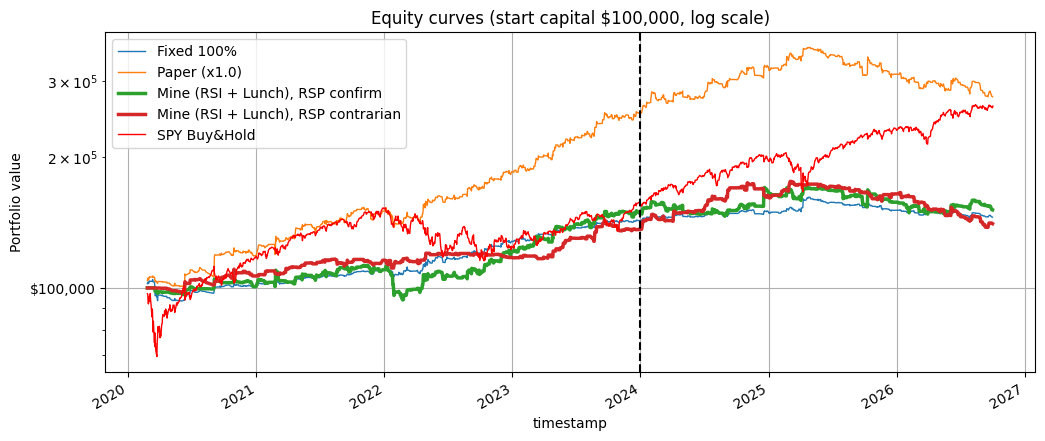

In [8]:
fig, ax = plt.subplots()
for name, returns in strategy_returns.items():
    compute_equity_curve(returns).plot(ax=ax, label=name, linewidth=2.5 if name in mine_names else 1)
compute_equity_curve(spy_returns).plot(ax=ax, label="SPY Buy&Hold", color="red", linewidth=1)
ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
ax.set_ylabel("Portfolio value")
ax.set_title("Equity curves (start capital $100,000, log scale)")
ax.legend()
plt.show()

## 6. Performance metrics by period

In [9]:
periods = {"Train": slice(None, TRAIN_END), "Test": slice(TEST_START, None)}

results = {}
for period_name, period in periods.items():
    rows = {}
    for name, returns in strategy_returns.items():
        rows[name] = compute_metrics(returns.loc[period], benchmark_returns)
    rows["SPY Buy&Hold"] = compute_metrics(spy_returns.loc[period])
    results[period_name] = pd.DataFrame(rows).T
    print(period_name)
    display(results[period_name].round(3))

Train


,total_return,annual_return,annual_volatility,sharpe_ratio,hit_ratio,max_drawdown,alpha,beta
Fixed 100%,0.431,0.098,0.081,1.310,0.500,0.108,0.106,-0.002
Paper (x1.0),1.536,0.274,0.148,1.878,0.500,0.101,0.282,-0.048
"Mine (RSI + Lunch), RSP confirm",0.487,0.109,0.125,0.977,0.490,0.168,0.122,-0.006
"Mine (RSI + Lunch), RSP contrarian",0.366,0.085,0.079,1.170,0.496,0.056,0.095,-0.024
SPY Buy&Hold,0.570,0.125,0.224,0.636,0.536,0.285,NaN,NaN


Test


,total_return,annual_return,annual_volatility,sharpe_ratio,hit_ratio,max_drawdown,alpha,beta
Fixed 100%,0.017,0.006,0.057,0.140,0.430,0.103,0.007,0.007
Paper (x1.0),0.088,0.031,0.145,0.285,0.430,0.230,0.052,-0.059
"Mine (RSI + Lunch), RSP confirm",0.017,0.006,0.128,0.112,0.409,0.132,0.031,-0.092
"Mine (RSI + Lunch), RSP contrarian",0.029,0.011,0.094,0.159,0.435,0.216,0.022,-0.038
SPY Buy&Hold,0.672,0.206,0.155,1.284,0.562,0.188,NaN,NaN


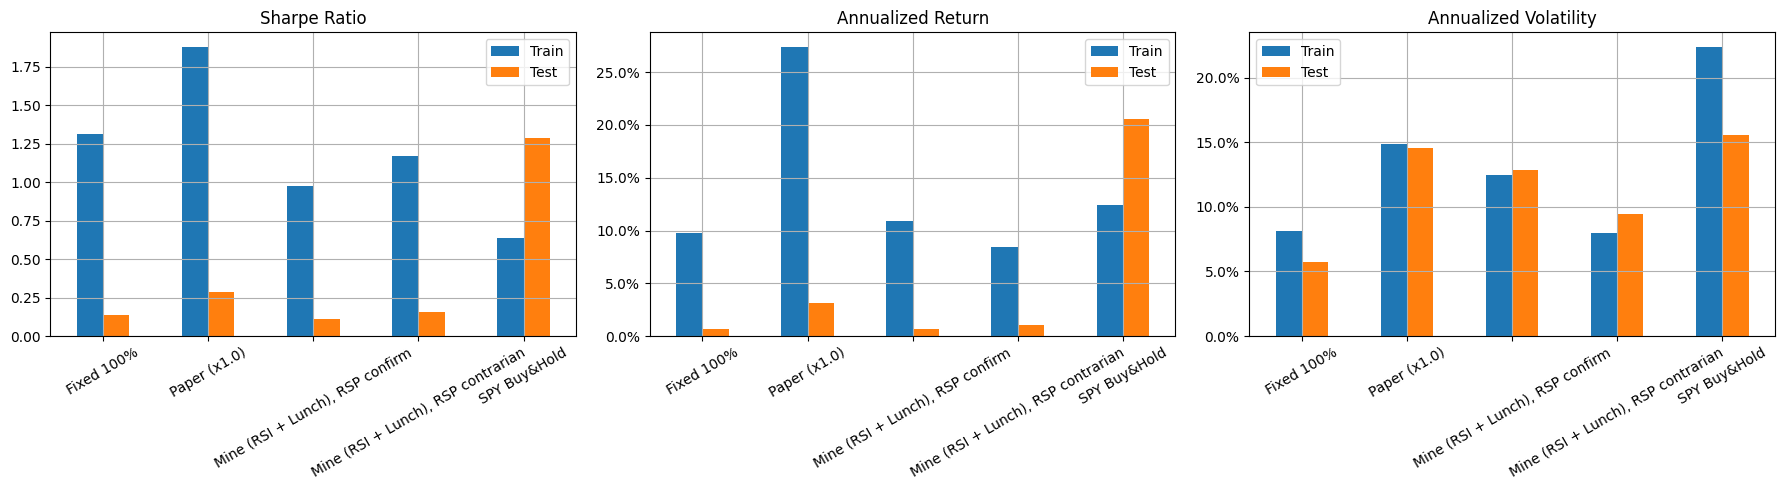

In [10]:
metric_titles = {
    "sharpe_ratio": "Sharpe Ratio",
    "annual_return": "Annualized Return",
    "annual_volatility": "Annualized Volatility",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title) in zip(axes, metric_titles.items()):
    table = pd.DataFrame({period_name: results[period_name][metric] for period_name in results})
    table.plot.bar(ax=ax, rot=30)
    ax.set_title(title)
    if metric != "sharpe_ratio":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

### Number of trades
A trade is one entry into a long or short position (a flip from long to short counts as a new trade). `count_daily_trades` in `my_strategy.py` runs the same daily simulation with one share, so trades = traded shares / 2. The fixed 100% variant trades exactly like the paper strategy and is left out.

Train                                    Test                                    Total                                 
                                   trades trades per day days with a trade trades trades per day days with a trade  trades trades per day days with a trade
Paper (x1.0)                        792.0           0.90             0.623  623.0           0.91             0.613  1415.0           0.91             0.618
Mine (RSI + Lunch), RSP confirm     498.0           0.57             0.456  308.0           0.45             0.376   806.0           0.52             0.421
Mine (RSI + Lunch), RSP contrarian  341.0           0.39             0.296  352.0           0.51             0.383   693.0           0.44             0.334

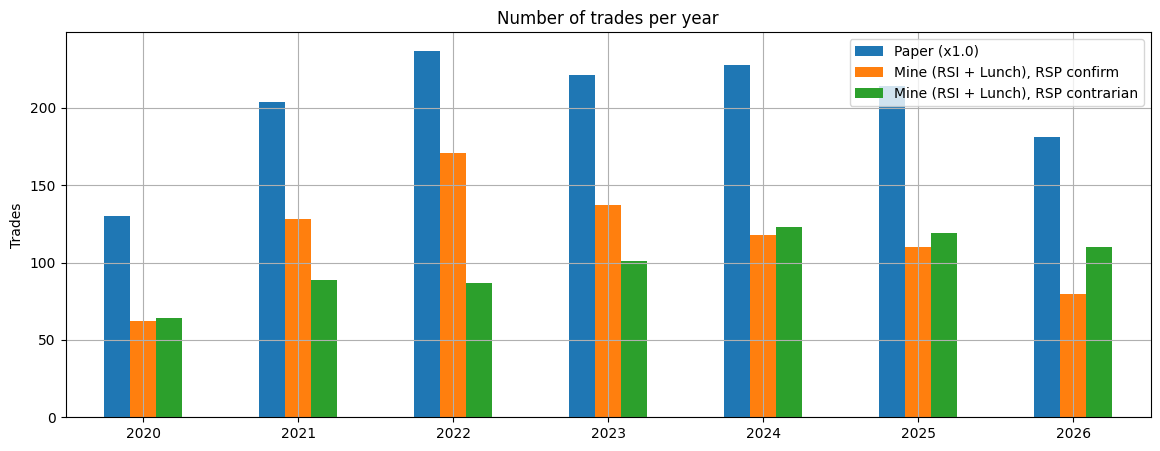

In [11]:
daily_trades = pd.DataFrame(
    {
        name: count_daily_trades(tables, STOP_MODE, rsp_tables=rsp_tables, days=common_days, **kwargs)
        for name, kwargs in variants.items()
        if name != "Fixed 100%"
    }
)

trade_summary = {}
for period_name, period in {**periods, "Total": slice(None, None)}.items():
    part = daily_trades.loc[period]
    trade_summary[period_name] = pd.DataFrame(
        {
            "trades": part.sum(),
            "trades per day": part.mean().round(2),
            "days with a trade": (part > 0).mean().round(3),
        }
    )
trade_summary = pd.concat(trade_summary, axis=1)
display(trade_summary)

ax = daily_trades.groupby(daily_trades.index.year).sum().plot.bar(figsize=(14, 5), rot=0)
ax.set_title("Number of trades per year")
ax.set_ylabel("Trades")
plt.show()

## 6b. Ablation
Every combination of RSI scaling (on/off), lunch filter (on/off) and RSP mode (off / confirm / contrarian), 2 × 2 × 3 = 12 variants with multiplier 1.0, all on the same days and with the same costs. `sharpe_vs_paper` is the change in Sharpe ratio versus the paper baseline in the same period. An add-on is only worth keeping if it improves the **train** Sharpe; the test column is shown for comparison and is not used for selection.

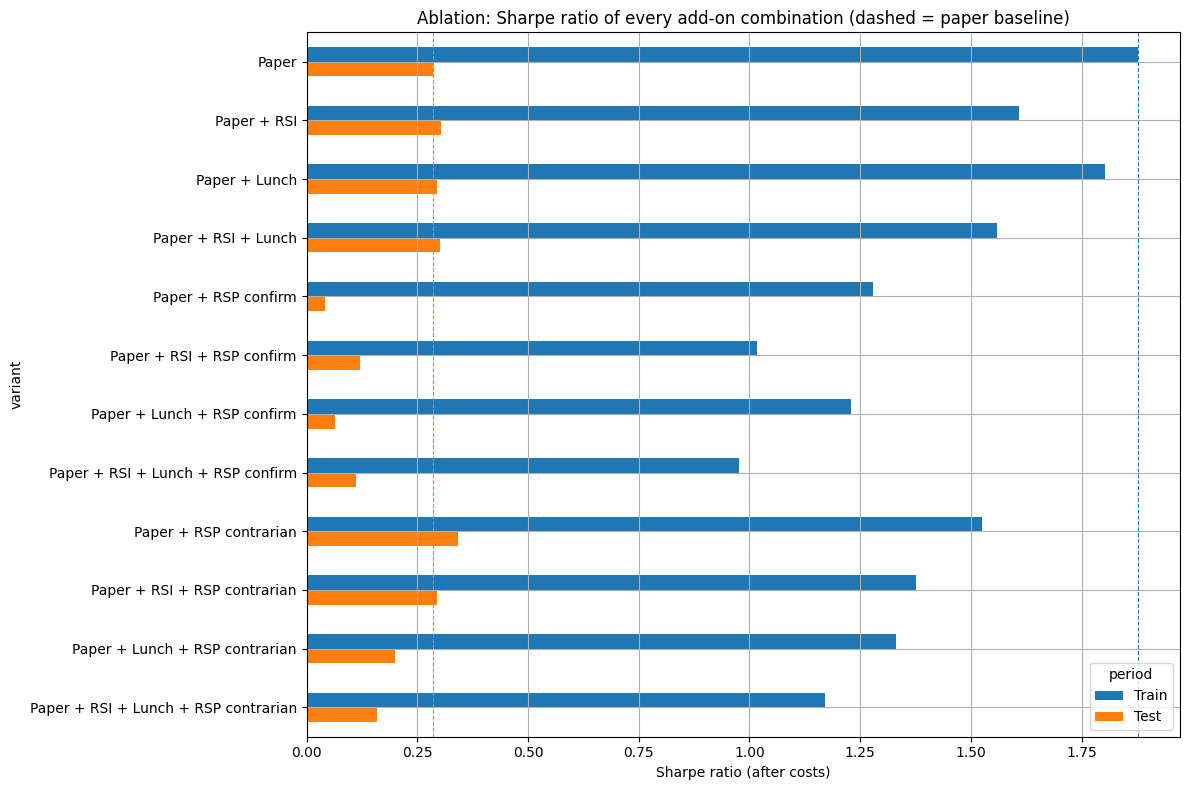

In [12]:
ablation = run_ablation(tables, rsp_tables, common_days, periods)
display(
    ablation.style.format(
        {
            "sharpe_ratio": "{:.2f}",
            "annual_return": "{:.1%}",
            "annual_volatility": "{:.1%}",
            "max_drawdown": "{:.1%}",
            "trades": "{:.0f}",
            "sharpe_vs_paper": "{:+.2f}",
        }
    ).background_gradient(cmap="RdYlGn", vmin=-0.6, vmax=0.6, subset=["sharpe_vs_paper"])
)

sharpe = ablation["sharpe_ratio"].unstack("period")[list(periods)]
sharpe = sharpe.loc[ablation.loc[list(periods)[0]].index]  # keep variant order
ax = sharpe.plot.barh(figsize=(12, 8))
ax.axvline(sharpe.loc["Paper", "Train"], color="C0", linestyle="--", linewidth=0.8)
ax.axvline(sharpe.loc["Paper", "Test"], color="C1", linestyle="--", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Sharpe ratio (after costs)")
ax.set_title("Ablation: Sharpe ratio of every add-on combination (dashed = paper baseline)")
plt.tight_layout()
plt.show()

## 6c. RSP filter: confirm vs. contrarian
The RSP filter alone on top of the paper strategy (no RSI scaling, no lunch filter), in both directions. The hypotheses:

- **Confirm**: a breakout carried by the whole market is a stronger imbalance and more likely to continue.
- **Contrarian**: in a market led by a few (tech/AI) mega caps, trends driven by the large caps are the persistent ones, so SPY breakouts *without* RSP are the better trades.

If breadth carried information about the quality of a breakout, one direction should earn clearly more per trade than the paper baseline and the other clearly less. The second table compares the yearly returns with the yearly breadth (RSP minus SPY price return).

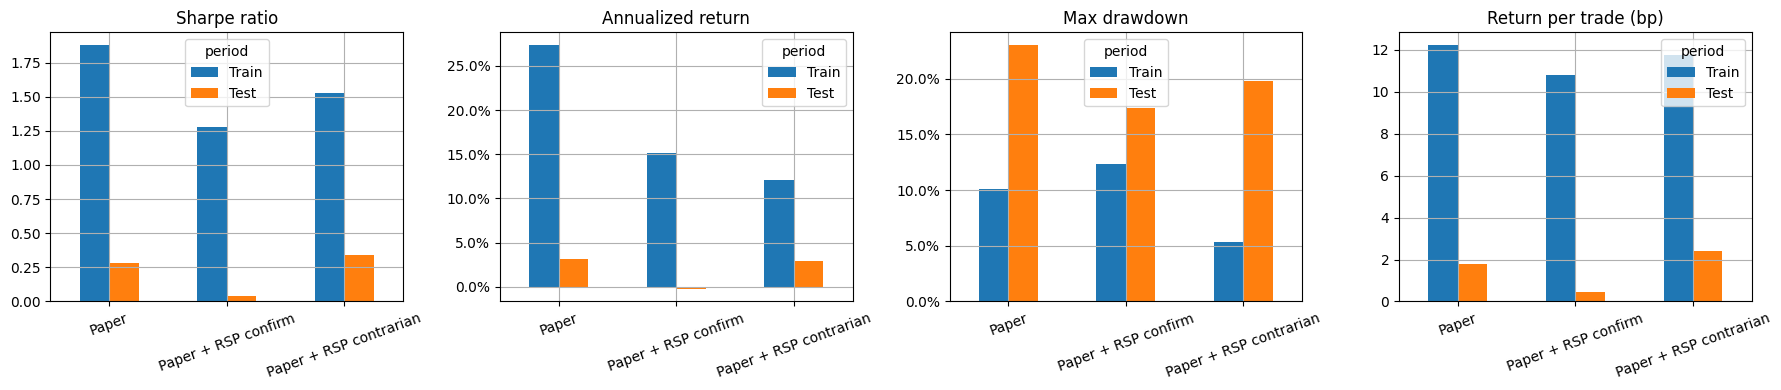

,Paper,Paper + RSP confirm,Paper + RSP contrarian,RSP - SPY (breadth)
Year,,,,
2020,+18.6%,+5.6%,+8.4%,-5.2%
2021,+26.8%,+11.5%,+10.4%,+0.8%
2022,+23.1%,+17.8%,+9.4%,+6.7%
2023,+36.9%,+24.1%,+18.5%,-13.0%
2024,+27.1%,+13.0%,+22.0%,-12.9%
2025,-3.5%,-7.0%,-2.2%,-7.0%
2026,-11.3%,-5.6%,-9.3%,-3.5%


In [13]:
# The RSP filter alone on top of the paper strategy, in both directions (same days and costs)
no_rsi_lunch = dict(use_rsi_scaling=False, use_lunch_filter=False)
rsp_runs = {}
for label, mode in [("Paper", "off"), ("Paper + RSP confirm", "confirm"), ("Paper + RSP contrarian", "contrarian")]:
    returns, _ = run_my_backtest(
        tables, STOP_MODE, rsp_mode=mode, rsp_tables=rsp_tables, days=common_days, **no_rsi_lunch
    )
    trades = count_daily_trades(
        tables, STOP_MODE, rsp_mode=mode, rsp_tables=rsp_tables, days=common_days, **no_rsi_lunch
    )
    rsp_runs[label] = (returns, trades)

rows = {}
for period_name, period in periods.items():
    for label, (returns, trades) in rsp_runs.items():
        m = compute_metrics(returns.loc[period])
        rows[(period_name, label)] = {
            "sharpe_ratio": m["sharpe_ratio"],
            "annual_return": m["annual_return"],
            "annual_volatility": m["annual_volatility"],
            "max_drawdown": m["max_drawdown"],
            "trades": trades.loc[period].sum(),
            # average net return per trade in basis points of the account (sum of daily returns / trades)
            "return per trade (bp)": returns.loc[period].sum() / trades.loc[period].sum() * 1e4,
        }
comparison = pd.DataFrame(rows).T
comparison.index.names = ["period", "variant"]
display(
    comparison.style.format(
        {
            "sharpe_ratio": "{:.2f}",
            "annual_return": "{:.1%}",
            "annual_volatility": "{:.1%}",
            "max_drawdown": "{:.1%}",
            "trades": "{:.0f}",
            "return per trade (bp)": "{:.1f}",
        }
    )
)

labels = list(rsp_runs)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (metric, title) in zip(
    axes,
    [
        ("sharpe_ratio", "Sharpe ratio"),
        ("annual_return", "Annualized return"),
        ("max_drawdown", "Max drawdown"),
        ("return per trade (bp)", "Return per trade (bp)"),
    ],
):
    comparison[metric].unstack("period")[list(periods)].loc[labels].plot.bar(ax=ax, rot=20)
    ax.set_title(title)
    ax.set_xlabel("")
    if metric in ("annual_return", "max_drawdown"):
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

# Yearly returns of the three variants next to the yearly breadth (RSP minus SPY, price returns)
yearly_rsp = pd.DataFrame({label: (1 + r).groupby(r.index.year).prod() - 1 for label, (r, _) in rsp_runs.items()})
spy_daily, rsp_daily = tables["close"].iloc[:, -1], rsp_tables["close"].iloc[:, -1]


def yearly_change(s):
    return s.groupby(s.index.year).last() / s.groupby(s.index.year).first() - 1


yearly_rsp["RSP - SPY (breadth)"] = yearly_change(rsp_daily) - yearly_change(spy_daily)
yearly_rsp.index.name = "Year"
display(yearly_rsp.style.format("{:+.1%}").background_gradient(cmap="RdYlGn", vmin=-0.3, vmax=0.3))

## 7. Yearly returns
The first and last year are partial (14-day warm-up in 2020, data until the end of the sample in 2026).

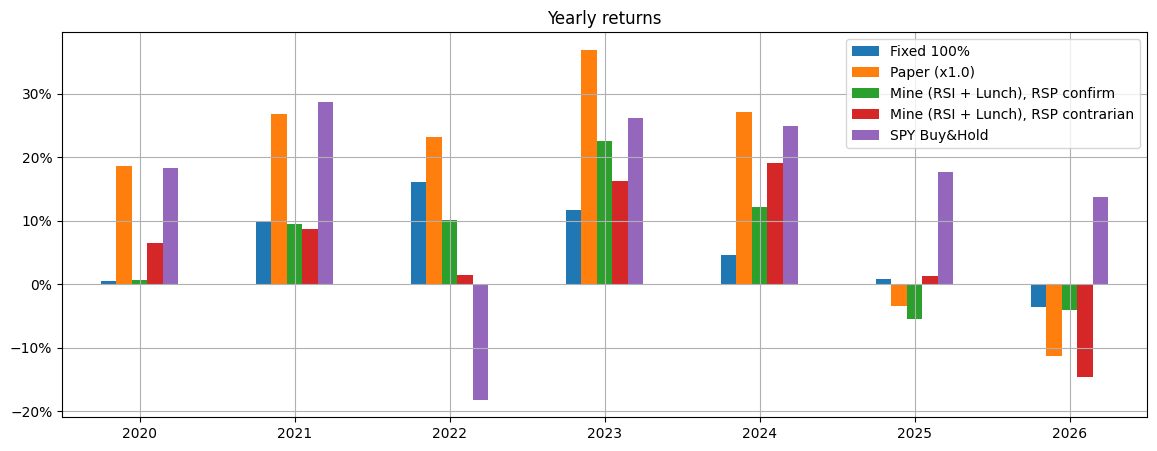

In [14]:
yearly = pd.DataFrame(
    {name: (1 + returns).groupby(returns.index.year).prod() - 1 for name, returns in strategy_returns.items()}
)
yearly["SPY Buy&Hold"] = (1 + spy_returns).groupby(spy_returns.index.year).prod() - 1

ax = yearly.plot.bar(figsize=(14, 5), rot=0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Yearly returns")
plt.show()

## 8. Drawdowns

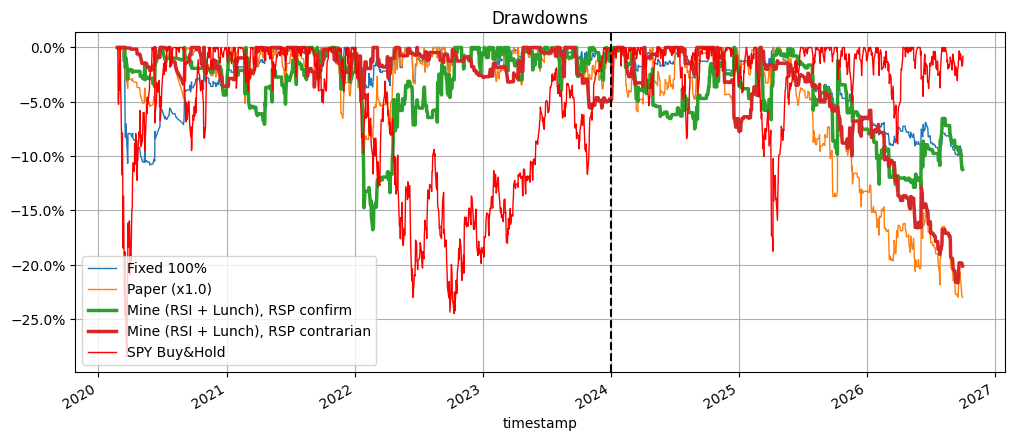

In [15]:
fig, ax = plt.subplots()
for name, returns in strategy_returns.items():
    equity = compute_equity_curve(returns)
    (equity / equity.cummax() - 1).plot(ax=ax, label=name, linewidth=2.5 if name in mine_names else 1)
spy_equity = compute_equity_curve(spy_returns)
(spy_equity / spy_equity.cummax() - 1).plot(ax=ax, label="SPY Buy&Hold", color="red", linewidth=1)
ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdowns")
ax.legend()
plt.show()

## 9. Monthly returns (like FAQ Q24 of the paper)
Same layout as the table in Q24 of the paper (compounded monthly returns in %, last column = yearly). Shown for the paper baseline and both RSP directions of my strategy. The first month of 2020 is partial (14-day warm-up).

In [16]:
from metrics import MONTH_NAMES, compute_q24_tables


def show_q24(returns, title):
    """Monthly table in the layout of FAQ Q24 of the paper (values in %) plus train/test summary."""
    table, summary = compute_q24_tables(returns, TEST_START)
    display(
        table.style.format("{:.1f}", na_rep="")
        .background_gradient(cmap="RdYlGn", vmin=-10, vmax=10, subset=MONTH_NAMES)
        .set_caption(title)
    )
    display(summary.round(3))
    return table


for name in strategy_returns:
    if name != "Fixed 100%":
        show_q24(strategy_returns[name], f"{name}: monthly returns in %")

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Yearly
Year,,,,,,,,,,,,,
2020,,4.4,-0.9,-1.5,-1.0,9.1,-0.1,-3.4,12.9,1.8,-0.6,-2.2,18.6
2021,5.3,2.7,0.9,5.9,2.1,-1.1,2.7,1.5,2.6,3.2,-5.3,3.9,26.8
2022,-6.4,2.9,0.2,9.0,2.1,-0.3,-0.1,5.9,-0.9,5.9,1.3,2.3,23.1
2023,2.8,-1.3,7.8,2.2,4.1,3.3,1.4,6.0,3.5,-1.3,0.5,3.1,36.9
2024,8.6,-1.3,-0.8,5.5,-4.4,1.5,8.1,-2.9,4.3,6.5,-4.0,4.2,27.1
2025,-1.4,7.7,-0.2,4.4,-2.1,-1.2,-2.4,-2.9,-5.4,5.7,-3.1,-1.8,-3.5
2026,-3.9,-0.4,0.6,-1.0,-3.3,3.9,-3.0,-1.3,-3.2,-0.1,,,-11.3


,annual_return,annual_volatility,sharpe_ratio,max_drawdown
Train,0.274,0.148,1.878,0.101
Test,0.031,0.145,0.285,0.230
Full,0.166,0.147,1.187,0.230


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Yearly
Year,,,,,,,,,,,,,
2020,,0.0,-2.0,-0.6,-0.2,3.5,-1.0,-0.2,3.5,1.6,-1.1,-2.6,0.7
2021,2.4,3.4,-3.4,2.7,1.0,-0.3,1.5,3.0,-0.1,0.8,-2.4,0.6,9.5
2022,-11.2,-1.6,3.1,7.9,1.5,-1.9,-1.1,4.3,-2.2,7.6,1.6,3.2,10.1
2023,2.5,0.4,4.2,3.2,1.4,3.0,1.8,1.7,0.6,1.3,0.3,0.2,22.6
2024,5.0,-0.2,-2.5,2.0,-4.3,-0.0,0.4,-1.5,2.7,2.9,-0.5,8.0,12.1
2025,-2.6,2.3,-2.3,4.3,-0.1,-0.8,-1.1,-1.6,-4.7,5.7,-2.6,-1.7,-5.4
2026,-2.9,0.8,-2.5,-0.2,0.0,3.0,0.8,-0.2,-2.6,-0.1,,,-4.0


,annual_return,annual_volatility,sharpe_ratio,max_drawdown
Train,0.109,0.125,0.977,0.168
Test,0.006,0.128,0.112,0.132
Full,0.065,0.126,0.592,0.168


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Yearly
Year,,,,,,,,,,,,,
2020,,0.0,-0.0,-0.7,-1.3,6.5,-0.6,-2.1,4.6,1.8,1.0,-2.4,6.6
2021,2.6,-1.3,2.4,0.9,2.5,0.3,1.3,-1.8,0.6,1.5,-2.8,2.5,8.7
2022,-0.7,1.5,-1.6,4.6,-0.8,0.5,-0.5,0.6,-0.8,0.0,-0.1,-1.3,1.4
2023,0.5,0.3,-0.5,3.2,4.3,2.7,-0.3,6.6,1.1,-2.6,0.1,0.2,16.3
2024,5.2,-0.0,-0.6,4.4,0.1,1.4,7.3,-2.3,7.1,2.4,-2.8,-3.8,19.1
2025,0.5,5.4,0.5,0.1,-0.8,-0.4,-1.0,-1.3,-1.0,-3.2,2.2,0.4,1.2
2026,-1.3,-2.8,-3.9,-0.2,-2.9,0.4,-3.1,-1.0,-0.8,-0.1,,,-14.6


,annual_return,annual_volatility,sharpe_ratio,max_drawdown
Train,0.085,0.079,1.170,0.056
Test,0.011,0.094,0.159,0.216
Full,0.053,0.086,0.681,0.216
